<a href="https://colab.research.google.com/github/74santos/local_inflation_commodity/blob/main/local_infaltion_commodity_sentinel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- COMMODITY SENTINEL REPORT: 2026-03-09 ---
                   Asset   Price  Daily_Change_%
0    Copper (Solar/Tech)    5.83            1.28
1  Crude Oil (Transport)   99.33            7.16
2      Wheat (Food Base)  618.50            1.14


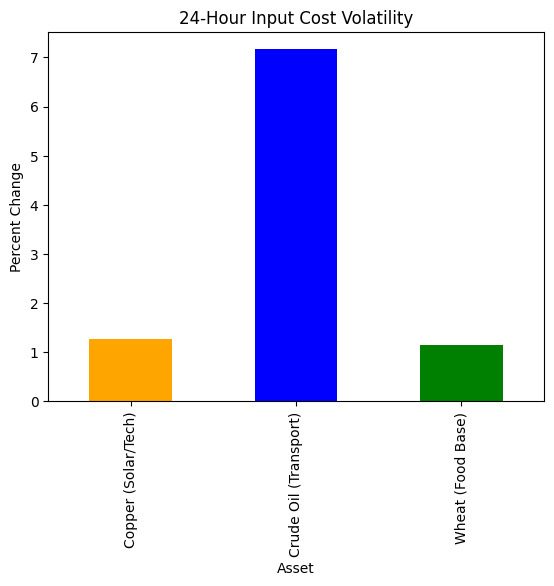

In [1]:
from IPython.core import prefilter
"""
PROJECT: Local Inflation & Commodity Sentinel
AUTHOR: Christian Santos
GOAL: Track the raw cost of inputs (Copper, Fuel, Wheat) to predict local price hikes.
"""

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

def track_commodity_stress():
    # Indicators: HG=F (Copper), BZ=F (Brent Crude), KE=F (Wheat)
    # Why Copper? It's 'Dr. Copper'—the only commodity with a PhD in economics
    commodities = {
        "HG=F": "Copper (Solar/Tech)",
        "BZ=F": "Crude Oil (Transport)",
        "KE=F": "Wheat (Food Base)"
    }

    print(f"--- COMMODITY SENTINEL REPORT: {datetime.now().strftime('%Y-%m-%d')} ---")

    report_data = []

    for ticker, name in commodities.items():
        try:
           # fetch last 30 days of data
           cmd = yf.Ticker(ticker)
           hist = cmd.history(period="30d")

           latest_price = hist['Close'].iloc[-1]
           prev_price = hist['Close'].iloc[-2]
           pct_change = ((latest_price - prev_price) / prev_price) * 100

           report_data.append({
               "Asset" : name,
               "Price" : round(latest_price, 2),
               "Daily_Change_%" : round(pct_change, 2)
           })

        except Exception as e:
            print(f"Could not fetch {name}: {e}")

    # Create a Clean Portfolio Table
    df = pd.DataFrame(report_data)


    # Logic: Highlight 'Inflation Spikes' (Changes > 2%)
    def highlight_stress(val):
        color = 'red' if val > 2 else 'green'
        return f'color: {color}'

    print(df)

    # 3. Portfolio Visual: Compare the three
    df.set_index('Asset')['Daily_Change_%'].plot(kind='bar', color=['orange', 'blue', 'green'])
    plt.title("24-Hour Input Cost Volatility")
    plt.ylabel("Percent Change")
    plt.axhline(0, color='black', linewidth=0.5)
    plt.show()

    return df


# RUN THE SENTINEL
inflation_df = track_commodity_stress()










